# Word Embeddings 


<div style="border:1px solid #ccc; border-radius:6px; padding:12px;">

<br>
<b>About</b><br><br>

This notebook is derived from the following notebook, with modifications and extensions: https://github.com/AI-Engineering-bootcamp/ai-eng-nbs-public/blob/master/ai-eng-nbs-4-master/s-403-404/2.%20Natural%20Language%20Processing%20II.ipynb
</div>


<br>

By the end of this session you should be able to:
---

- Explain what word embeddings are and why they matter
- Describe how Word2vec learns embeddings from raw text
- Distinguish between Skip-gram and CBOW training approaches
- Understand how embeddings can be applied in many different fields



<br>

What are Word Embeddings?
-----

Word embeddings are numerical representations of words as **dense vectors** — simply a list of numbers, like `[0.25, -0.1, 0.8, ...]`. These numbers are decimals (floating-point), and the list is relatively short and compact (hence *dense*, as opposed to mostly-zero lists). 

![embeddings_diagram_1](../_images/embeddings_diagram_1.png)

<br>

Instead of treating each word as an isolated symbol, embeddings place words in a continuous vector space where **similar words end up close to each other**.

For example, the words *king* and *queen* will have vectors that are much closer together than *king* and *bicycle* — because their meanings and contexts are more similar.

<div style="background: #fff; display: inline-block;">
<img src="../_images/embeddings_diagram_3.svg" style="background: #fff;"/>
</div>


<br>

Worth mentioning: 
- These diagrams are simplified. In practice, embeddings are vectors in a high-dimensional space (that is, vectors with many dimensions). 
- For the sake of visualization, they're often projected into two or three dimensions (2D / 3D) so they're easier for humans to interpret.

<br>

Why are Embeddings important?
-----

Embeddings are important for three key reasons:

1. **They capture meaning.** Unlike simple encodings (e.g. one-hot), embeddings represent *semantic relationships* — words with similar meanings end up with similar vectors. This means a model can understand that *dog* and *puppy* are related, even if it has never seen them in the same sentence.

2. **They are compact and efficient.** A vocabulary of 100,000 words would need 100,000-dimensional one-hot vectors. Embeddings can represent the same vocabulary in just 100–300 dimensions, making them far cheaper to store and compute with.

3. **They are reusable.** Pre-trained embeddings (trained on billions of words) can be plugged directly into your own model, giving it a head start without needing massive amounts of labelled data. This is a form of **transfer learning**.


<br>
<hr>
<hr>
<br>

Research:
- How are embeddings used in modern AI?
- What are common applications?

Time: 10 minutes.

<br>
<hr>
<hr>
<br>

<br>

Embeddings Across Modalities
-----

In this notebook, we will focus on Word Embeddings. However, it is worth to mention that embeddings are not limited to text. 

The core idea —representing an object as a vector in a continuous space where similar objects are close together— applies across many modalities.

Here are some common examples:

| Modality | What gets embedded | Similar items end up close because... |
|----------|---------------------|----------------------------------------|
| Text | Words, sentences, documents | They have similar meaning or context |
| Images | Photos, drawings | They depict similar objects or scenes |
| Audio | Speech, music, sounds | They sound similar or contain similar content |
| Video | Clips or frames | They contain similar actions or events |
| Code | Functions, files | They perform similar tasks or have similar structure |
| Proteins/DNA | Biological sequences | They have similar biological properties |

<br>

![embeddings_modalities](../_images/embeddings_modalities.png)


<br>

Word Embeddings basic example
----


Let's start with a very basic example of how embeddings may actually look like...

In [1]:
# Represent data
corpus = """The man and woman meet each other ...
         The man and woman become king and queen ...
         The king and queen get old and stop talking to each other. Instead, they read books and magazines ...
         """

In [2]:
import numpy as np

# Assign important words to vectors by hand
important_words = ['queen', 'book', 'king', 'magazine', 'woman', 'man']

vectors = np.array([[0.1,   0.3],  # queen
                    [-0.5, -0.1],  # book
                    [0.2,   0.2],  # king
                    [-0.3, -0.2],  # magazine
                    [-0.5,  0.4],  # car
                    [-0.45, 0.3]]) # bike

In [3]:
import matplotlib.pyplot as plt

%matplotlib inline

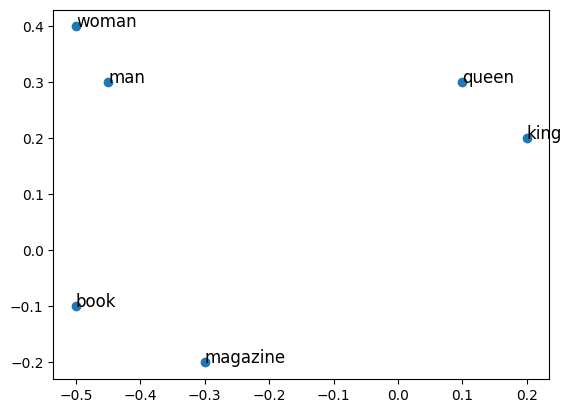

In [4]:
# Plot the most important words
plt.plot(vectors[:,0], vectors[:,1], 'o')
for word, x, y in zip(important_words, vectors[:,0], vectors[:,1]):
    plt.annotate(word, (x, y), size=12)

<br>

### Check for understanding


<details>
  <summary>How many dimensions have we used to represent the data? </summary>
  
  <br />

  2 dimensions

</details>


<br>

<details>
  <summary>If we were using Bag of Words, or TF-IDF, how many dimensions we'd need to represent the same data?</summary>
  
  <br />

  6 dimensions (one dimension for each unique word in the vocabulary when using Bag of Words or TF-IDF).

  Example:

  ```
    queen     → [1, 0, 0, 0, 0, 0]
    book      → [0, 1, 0, 0, 0, 0]
    king      → [0, 0, 1, 0, 0, 0]
    magazine  → [0, 0, 0, 1, 0, 0]
    woman     → [0, 0, 0, 0, 1, 0]
    man       → [0, 0, 0, 0, 0, 1]
  ```

  💡 In contrast to other NLP encodings which are larger and sparser, embeddings allow to create low-dimensional, dense vectors

</details>




<br>

Word2vec
----

**Word2vec** (Tomas Mikolov et al., Google, 2013) is a family of shallow neural network models for learning word embeddings and is one of the most influential approaches in the history of NLP.

Given a large text corpus, it produces a dense vector for every word in the vocabulary — vectors that encode semantic relationships purely from the statistics of which words appear near which other words.

Key properties at a glance:

| Property | Value |
|----------|-------|
| Output | One dense vector per word |
| Typical dimension | 100 – 300 |
| Training data | Raw, unlabelled text |
| Training time | Minutes to hours (depending on corpus size) |
| Captures | Semantic similarity, analogies (king − man + woman ≈ queen) |

Word2vec was a breakthrough because it showed that a very simple neural network, trained on a self-supervised task, could learn surprisingly rich representations of meaning — without any human annotation.

<br>

Note:
- Word2vec learns embeddings for individual words only. Each word in the vocabulary is assigned a single fixed vector, regardless of the sentence in which it appears.
- It does not directly produce embeddings for sentences or documents (to obtain embeddings for larger pieces of text, there's specialized models like Doc2Vec, SBERT, etc)




<br>

How does Word2vec work?
----

Word2vec learns the meaning of words by observing the **context** in which they appear — the words that surround them in a sentence.

It does this by training a shallow neural network on a simple **self-supervised prediction task**: given a center word, predict which words tend to appear nearby (or vice versa). No human labels are needed — the text itself provides all the supervision.

The core insight: words that appear in similar contexts are trained on similar signals, so their learned weight vectors end up pointing in similar directions. Those weights *are* the embeddings.


>
> “You shall know a word by the company it keeps”
> \- J. R. Firth 1957
>

This idea — that context reveals meaning — is formalized as the **Distributional Hypothesis**, and it is exactly what Word2vec uses to turn raw text into vectors.

<br>

Distributional Hypothesis
----

> Words that are used and occur in the same contexts tend to have similar meanings

Example:

- The _plant_ absorbs _water_ and _nutrients_ from the soil.
- The _tree_ absorbs _water_ and _nutrients_ through its _roots_.

The words _water_, _nutrients_, _roots_, and _growth_ frequently appear near both _plant_ and _tree_, suggesting that these words have related meanings because they occur in similar contexts.


The words: _cinema_ and _basketball_ probably do __not__ represent some aspect of plants since they do not frequently appear near by.

<br>

**Why does this lead to similar vectors?**

During training, every time Word2vec processes a sentence like *"the _plant_ absorbs water and nutrients from the soil"*, it nudges the vector for *plant* slightly toward the vectors for *water* and *nutrients* — because they appeared nearby.

The same nudge happens in the second sentence: *tree* is also surrounded by *water* and *nutrients*.

After processing millions of sentences:
- *plant* and *tree* end up with **similar vectors** — they were repeatedly trained on overlapping context words
- *tree* and *cinema* end up **far apart** — their contexts rarely overlapped

This is the Distributional Hypothesis turned into a training signal.


<br>

Two architectures: CBOW and Skip-gram
---

Word2Vec comes in two main variants (two training architectures), both based on the Distributional Hypothesis. 

The key difference lies in the direction of the prediction task: one predicts a target word from its surrounding context, while the other predicts the surrounding context from a target word.

<br>

| Architecture | Input | Prediction target | Intuition |
|---|---|---|---|
| **CBOW** (Continuous Bag of Words) | the surrounding context words | the center word | *"Given quick, brown, jumps, over — predict **fox**"* |
| **Skip-gram** | one center word | the surrounding context words | *"Given **fox**, predict quick, brown, jumps, over"* |

<br>

**CBOW** — averages all context word vectors and feeds that average to a neural network to predict the center word. It trains faster and tends to work better on frequent words, making it the practical choice for large corpora.

**Skip-gram** — feeds the center word into a neural network and asks it to predict each context word. It sees one word at a time, so it generates many training examples per sentence. This makes it slower to train but better at capturing rare words and nuanced relationships.

<br>

![word2vec-architectures](../_images/word2vec-architectures.png)

<br>

In practice, neither architecture is universally better:
- CBOW trains faster and performs well for common words.
- Skip-gram generally yields higher-quality embeddings—especially for infrequent words.

The choice depends on the size of the corpus and whether embedding quality or training efficiency is the primary goal.



<br>

Word2vec (skip-gram): how does it work
---

**The goal:**
- Word2vec wants to turn each word into a vector of numbers (an "embedding") such that words with similar meanings end up with similar vectors. 
- It does this indirectly: by training a model to predict context from a word, and then using what the model learned (not its predictions) as the embeddings.

<br>

**Step 1: Slide a window over the text**

- Sentence: `the quick brown fox jumps over`

- Pick a window size, say 2 — meaning "look at 2 words to the left and 2 words to the right."

- Go word by word, treating each one as the target (the word we're focusing on), and grab the words around it as context.

- For example, if `target = fox`, and `window = 2`:

<br>
<pre>
the  [quick  brown  fox  jumps  over]
                     ↑target
</pre>
<br>

Context words: `quick`, `brown`, `jumps`, `over` (they all fall within distance 2)

<br>

**Step 2: Turn this into training examples**

Skip-gram flips things around: instead of predicting the target from context, it predicts each context word from the target, one at a time.

So target fox produces 4 separate training examples:

| Input (target) | Output (context word / words that need to be predicted by the model) |
|---|---|
| fox | quick |
| fox | brown |
| fox | jumps |
| fox | over |


Each pair is a learning signal: 
- The model is trained to assign high probability to context words given the center word. 
- A pair that appears multiple times simply reinforces that association more strongly.

Very frequent words like "the" and "a" appear near every word and carry little meaningful information, so in practice they are downsampled to prevent them from dominating training.


Worth to mention: the model isn't predicting one fixed word. It outputs a probability distribution over the entire vocabulary — basically "how likely is each word in the vocabulary to be near fox?"

So for input `fox`:
- Training example 1 says: nudge the weights so `quick` gets a higher probability.
- Training example 2 says: nudge the weights so `brown` gets a higher probability.
- Training example 3 says: nudge the weights so `jumps` gets a higher probability.
- Training example 4 says: nudge the weights so `over` gets a higher probability.

<br>

**Step 3: Repeat for every word in the sentence**

Now slide the window to the next target, `jumps`:

<br>
<pre>
the  [quick  brown  fox  jumps  over]
                          ↑target
</pre>
<br>

...and so on for every word in the sentence. You end up with a big list of (target → context) pairs across the whole corpus.

<br>

**What the model actually does with these pairs**

- Every word in the vocabulary gets a random starting vector (e.g., 100 random numbers).
- For a pair like (fox → brown), the model takes fox's current vector and tries to compute a score/probability that brown is a nearby word — basically comparing fox's vector to every other word's vector and asking "how close are these?"
- Since the correct answer here is "brown," the model nudges fox's vector and brown's vector closer together (and nudges unrelated words' vectors away).

In [5]:
# 
# This video illustrates how the weights start random...
# ... then get updated and separate during each training pass.
# 

# Training: From random to clustering
from IPython.display import VimeoVideo

VimeoVideo("112168934")


<br>


**Training drives similar words together**
- This process is done **millions of times**
- Across a huge corpus, words that repeatedly show up in similar contexts (like `king` and `queen`, or `dog` and `cat`) get nudged toward similar vectors — because they keep getting paired with similar surrounding words.
- End result: the "predicting context" task is just a means to an end. What you actually keep is the word vectors that got learned along the way — that's the word2vec embedding.




<br>

Word2vec (skip-gram): architecture 
---


**Skip-gram neural network architecture**


Word2Vec (Skip-gram) is a shallow neural network with an input layer, one hidden (embedding) layer, and an output layer:

- **Input layer** — The center word is represented as a **one-hot vector**: a vector of length V (vocabulary size) that is all zeros except for a single 1 at the index of that word. This is a purely symbolic representation — it encodes *which* word it is, but carries no meaning by itself.

- **Hidden layer** — This is the key layer. It is a weight matrix of shape `(V × D)`, where D is the embedding dimension. When the one-hot input is multiplied by this matrix, the result is simply the **row corresponding to the input word** — that row *is* the word's embedding. The hidden layer is much smaller than the input and output (D ≪ V), which forces the network to compress information into a compact representation.

- **Output layer** — A softmax over the full vocabulary that produces a probability distribution: *"given this center word, how likely is each vocabulary word to appear as a context word?"* The training target is to make the true context words score high.

<br>

| Layer | Size | Role |
|-------|------|------|
| Input | vocab size (ie. as many inputs as words in the vocabulary) | one-hot vector for the **center word** |
| Hidden | embedding dim (e.g. 100–300) | weight matrix — **each row is one word's embedding** |
| Output | vocab size | softmax — probability distribution over all context words |

Looking up a word's embedding is simply selecting its row from the hidden weight matrix.

<br>

Because `fox`*, `wolf`*, and `tiger`* are repeatedly trained to predict (or be predicted by) similar context words such as `animal`, `mammal`, and `wild`, their embedding vectors receive similar updates over many training examples. As a result, their vectors gradually converge to nearby locations in the embedding space.

<br>

**CBOW difference:** 
- In CBOW the roles are reversed — the context word vectors are averaged together and fed as input, and the network predicts the center word. 
- The architecture is otherwise identical; only the direction of the prediction task changes.


<br>

What we keep after training: the hidden layer weights
---

The prediction task — given a center word, predict its context words — was never the real goal. It was a training mechanism designed to force the network to learn useful internal representations.

The actual output we care about lives in the **hidden layer weight matrix**. After training, the output softmax layer is discarded entirely. The hidden layer weights are what we keep:

<pre>
Hidden weight matrix  (V rows × D columns)

  row 0  →  embedding for word 0   →  [ 0.12, -0.45,  0.88, ... ]
  row 1  →  embedding for word 1   →  [-0.33,  0.71, -0.09, ... ]
  row 2  →  embedding for word 2   →  [ 0.55,  0.02,  0.41, ... ]
  ...
  row i  →  embedding for word i   →  [ ...,   ...,   ...,  ... ]
</pre>

This matrix is the **embedding table** — a lookup table with one row per word in the vocabulary. To get the embedding for any word, retrieve its row by index. That dense vector of D numbers is the word's final representation.

In summary:
- The **output layer** was a training scaffold — used only to compute loss and drive learning. It is thrown away.
- The **hidden layer** is the result — its weights have been shaped by training to encode meaning. Words that appeared in similar contexts ended up with similar rows.


<br>

Autoencoders
-------

An **autoencoder** is a neural network trained to reproduce its input at the output, while passing through a **bottleneck** — a hidden layer that is much smaller than the input and output.

<center><img src="https://upload.wikimedia.org/wikipedia/commons/2/28/Autoencoder_structure.png" width="700"/></center>

It has two parts:
- **Encoder** — compresses the high-dimensional input into a compact, dense representation (the *latent space* or *embedding*).
- **Decoder** — reconstructs the original input from that compact representation.

Because the network is forced to reconstruct the input through the bottleneck, it must learn to capture the most important structure of the data in a small number of dimensions — discarding noise and redundancy.

<br>

**Connection to Word2vec**

Word2vec is a form of autoencoder applied to text:

| Autoencoder concept | Word2vec equivalent |
|---------------------|---------------------|
| High-dimensional input | One-hot vector (size = vocabulary) |
| Bottleneck / latent layer | Hidden weight matrix (100–300 dims) — the embeddings |
| Reconstruction output | Predicted context words (softmax over vocabulary) |

The one-hot input is sparse and enormous (one dimension per word in the vocabulary). The hidden layer forces the network to compress each word into a small dense vector. After training, the decoder (output softmax) is thrown away — the **encoder weights (the embeddings) are what we keep**.

This is exactly what makes Word2vec powerful: the bottleneck forces the model to encode *meaning* rather than just memorizing word identities.


<br>

Use Cases and Applications
----

Word embeddings power a wide range of real-world applications:

| Application | How embeddings are used | Example |
|---|---|---|
| **Search engines** | Match a query to semantically similar documents, not just keyword matches | Google returns results for *"car insurance"* even if a page says *"auto coverage"* |
| **Recommendation systems** | Represent items (products, movies, songs) as vectors; recommend items with similar vectors | Spotify's recommendation engine embeds songs and users in the same space to find music you might like |
| **Chatbots & virtual assistants** | Map user input to the closest known intent | A support bot recognises *"my order hasn't arrived"* and *"where is my package?"* as the same intent |
| **Sentiment analysis** | Use embedding similarity to classify text as positive, negative, or neutral | Product review analysis at scale for Amazon, Yelp, etc. |
| **Fraud detection** | Embed sequences of transactions; flag sequences that are far from normal behaviour | Banks use this to detect unusual spending patterns in real time |
| **Biomedical NLP** | Embed medical terms so that *"myocardial infarction"* is close to *"heart attack"* | Clinical NLP systems that extract diagnoses from doctor's notes |

<br>

In modern AI systems, word embeddings are often a **first step in a larger pipeline** — the learned representations are fed into downstream models (classifiers, generative models, retrieval systems) rather than used in isolation.

<br>

---

### (Bonus) Case Study: Spotify

Embeddings play an essential role in Spotify's recommendation engines. Spotify represents songs, artists, playlists, and listeners as embedding vectors. Items with similar embeddings are likely to share musical characteristics or listener preferences, allowing recommendation models to efficiently retrieve relevant content.

During a 2025 presentation, Spotify engineer Niklas Stål described embeddings as:

> "Embeddings serve as fingerprints for everything we have—artists, tracks, listeners, playlists."

This highlights an important idea: modern recommendation systems learn embeddings not only for content but also for users and their interactions, making personalized recommendations both scalable and effective.

If you'd like to learn more about how Spotify uses embeddings, explore the following resources:

- Some notes: https://chatgpt.com/share/6a4e539c-c230-83ed-8abb-040c02065310

- Article "Inside Spotify's Content Recommendation Engine": https://learn.scale.com/public/blogs/inside-the-content-recommendation-engine-at-the-heart-of-spotify

<br>

Summary
----

- **Word Embeddings** are dense, low-dimensional vectors that represent words as numbers — similar words end up with similar vectors
- **Why they matter:** they capture semantic meaning, are compact (100–300 dims vs. vocabulary-sized one-hot vectors), and enable transfer learning with pre-trained models
- **Embeddings are not limited to text** — the same idea applies to images, audio, video, code, and biological sequences
- **Distributional Hypothesis:** words that appear in similar contexts have similar meanings — this is the core principle behind Word2vec
- **Word2vec** (Google, 2013) trains a shallow neural network on a self-supervised prediction task to produce one dense vector per word
- **Two training architectures:**
  - **Skip-gram** — given a center word, predict surrounding context words (better for rare words)
  - **CBOW** — given context words, predict the center word (faster, better for frequent words)
- **What we keep after training:** the hidden layer weight matrix — one row per word — is the embedding table; the output layer is discarded
- **Autoencoders** share the same idea: compress a high-dimensional input through a bottleneck to learn a compact, meaningful representation
